# 🧹 Data Preprocessing in Data Science

Real-world data is **messy**: missing values, duplicates, typos, inconsistent
categories, outliers, and features on wildly different scales. Models can't
learn well from messy data — *"garbage in, garbage out."*

**Today we'll cover the core preprocessing steps, in the order you usually do them:**

1. Explore & understand the data
2. Handle **missing values**
3. Remove **duplicates**
4. Clean **inconsistent / dirty categorical** data
5. Detect & treat **outliers**
6. **Encode** categorical variables
7. **Scale** numeric features
8. **Train/test split** (and why order matters — data leakage)
9. Bonus: putting it together with a `Pipeline`

> 💡 There is no single "correct" recipe. Preprocessing depends on your data,
> your model, and your goal. The techniques below are your toolbox.
>
> ⏱️ Subsections marked **"(If time permits)"** are optional depth — skip them
> if the hour is running short; they're great self-study material.

## 0. Setup
Import the libraries we'll use throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries loaded ✔")

Libraries loaded ✔


## 1. Create a messy dataset

To keep this notebook self-contained (no downloads needed), we'll **generate a
synthetic HR dataset** of employees — and deliberately inject the kinds of
problems you meet in real life. We save it to a CSV and read it back, just like
a real project.

In [2]:
rng = np.random.default_rng(42)   # reproducible randomness
n = 200

departments = ["Sales", "Engineering", "HR", "Marketing", "Finance"]
cities = ["Karachi", "Lahore", "Islamabad", "Multan", "Peshawar"]
education_levels = ["High School", "Bachelor", "Master", "PhD"]  # has a natural ORDER

df = pd.DataFrame({
    "emp_id":        np.arange(1, n + 1),
    "age":           rng.normal(35, 8, n).round(0),
    "gender":        rng.choice(["M", "Male", "male", "F", "Female", "female"], n),
    "department":    rng.choice(departments, n),
    "city":          rng.choice(cities, n),
    "education":     rng.choice(education_levels, n, p=[0.2, 0.45, 0.28, 0.07]),
    "experience":    rng.normal(8, 4, n).round(1).clip(0, None),
    "salary":        rng.normal(80_000, 25_000, n).round(0),
    "satisfaction":  rng.integers(1, 6, n).astype(float),  # 1..5 rating
    "attrition":     rng.choice(["Yes", "No"], n, p=[0.25, 0.75]),  # target
})

# --- Inject real-world messiness ------------------------------------------
# 1) Missing values
df.loc[rng.choice(n, 25, replace=False), "salary"] = np.nan
df.loc[rng.choice(n, 15, replace=False), "age"] = np.nan
df.loc[rng.choice(n, 10, replace=False), "satisfaction"] = np.nan

# 2) Outliers (data-entry errors: extra zero, impossible age)
df.loc[5, "salary"] = 950_000
df.loc[12, "salary"] = 850_000
df.loc[7, "age"] = 150

# 3) Inconsistent whitespace / casing in a text column
df.loc[rng.choice(n, 30, replace=False), "city"] = "  lahore  "

# 4) Duplicate rows
df = pd.concat([df, df.iloc[[0, 1, 2]]], ignore_index=True)

df.to_csv("employees_messy.csv", index=False)
print("Saved employees_messy.csv with shape", df.shape)

Saved employees_messy.csv with shape (203, 10)


## 2. First look — *always* explore before you clean

Before touching anything, understand what you have. These are the commands you
run at the start of **every** project.

In [3]:
df = pd.read_csv("employees_messy.csv")
df.head()

,emp_id,age,gender,department,city,education,experience,salary,satisfaction,attrition
0,1,37.0,female,Finance,Lahore,Bachelor,9.5,79692.0,1.0,No
1,2,27.0,M,Finance,Peshawar,Master,9.7,74476.0,3.0,No
2,3,41.0,Male,Finance,Karachi,Bachelor,9.6,77414.0,3.0,No
3,4,43.0,Male,HR,Peshawar,Master,7.3,79300.0,4.0,No
4,5,19.0,Male,Marketing,Multan,Bachelor,11.3,85639.0,5.0,No


From looking at these columns, we see that the definitions are:
- emp_id: The id of the employee.
- age: The age of the employee.
- gender: The gender of the employee.
- department: Which department they work in.
- city: This is the city that they either wrok in or live in.
- education: This is the highest level of education they have.
- experience: This is the number of years of experience they have in years.
- salary: This is the salary the employee earns.
- satisfaction: This is the level of satisifcation of the employee.
- attribution: This indicates if the employee has left the company or still remains.

Interesting things I have noticed.
- Gender has some inconsistency in how it is represented. Sometimes it is "M", sometimes it's "Male.

In [4]:
print("Shape (rows, cols):", df.shape)
df.info()

Shape (rows, cols): (203, 10)
<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   emp_id        203 non-null    int64  
 1   age           189 non-null    float64
 2   gender        203 non-null    str    
 3   department    203 non-null    str    
 4   city          203 non-null    str    
 5   education     203 non-null    str    
 6   experience    203 non-null    float64
 7   salary        178 non-null    float64
 8   satisfaction  193 non-null    float64
 9   attrition     203 non-null    str    
dtypes: float64(4), int64(1), str(5)
memory usage: 16.0 KB


We see there are 203 rows in our data.
Some columns have missing values For example:
- Age has 14 missing values.
- Salary has 25 missing values
- Satisfaction has 10 missing values.

Also when looking through the data-types we notice some odd types for some variables.
- Age is given as a float when we are used to thinking about it as an integer.
- Satisfaction is given as a float but that might be ok since some people may rate as point 5.

In [5]:
# Summary statistics for numeric columns — watch the min/max for weird values
df.describe()

,emp_id,age,experience,salary,satisfaction
count,203.000000,189.000000,203.000000,178.000000,193.000000
mean,99.044335,35.248677,7.924631,90034.146067,2.880829
std,58.670442,10.891465,3.896290,89719.688065,1.399887
min,1.000000,18.000000,0.000000,-11210.000000,1.000000
25%,48.500000,30.000000,5.100000,68071.250000,2.000000
50%,99.000000,35.000000,8.100000,81134.500000,3.000000
75%,149.500000,39.000000,10.550000,95249.750000,4.000000
max,200.000000,150.000000,20.700000,950000.000000,5.000000


👀 **What to look for already:**
- `age` max is **150** → impossible, likely an outlier / data-entry error.
- `salary` max is huge compared to the mean → outlier.
- `Non-Null Count` in `.info()` is below the row count for `salary`, `age`,
  `satisfaction` → **missing values**.

## 3. Handling missing values

First, **measure** the problem. Then choose a strategy per column.

**Why is the data missing?** It matters, because it changes what's safe to do:

- **Missing completely at random** — a sensor glitched, a form field got skipped
  randomly. Safe to drop or impute.
- **Missing for a reason related to other columns** — e.g., junior employees
  skip the salary field more often. Simple imputation can distort patterns;
  smarter (group-wise) imputation helps.
- **Missing because of the value itself** — e.g., high earners refuse to
  disclose salary. The most dangerous kind: the gaps *are* information.
  Sometimes the best move is a **"was missing" indicator column**.

Common strategies:
| Strategy | When to use | Watch out for |
|---|---|---|
| **Drop rows** | Very few rows affected, plenty of data | You may silently throw away a biased subset |
| **Drop column** | Column is mostly empty (rule of thumb: >50–60%) / not useful | Might still carry signal — check first |
| **Impute (fill)** | You want to keep the data | **Mean** is distorted by outliers → prefer **median**; **mode** for categories |
| **Group-wise impute** | Fill using the median *of similar rows* | Needs a sensible grouping column |
| **Missing indicator** | The fact it's missing may itself be predictive | Adds a column per feature |

In [6]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "percent": missing_pct}) \
    .query("missing > 0").sort_values("missing", ascending=False)

,missing,percent
salary,25,12.3
age,14,6.9
satisfaction,10,4.9


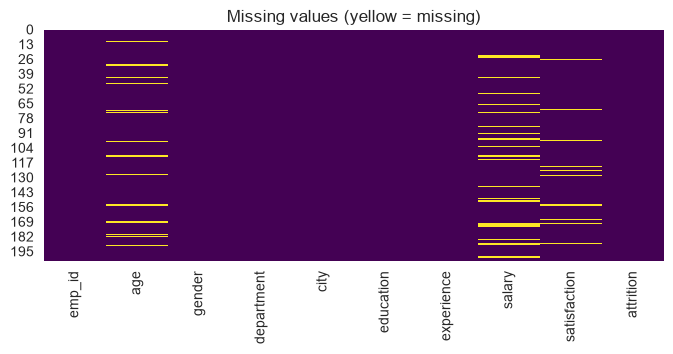

In [7]:
# Visualize where the gaps are (a heatmap of "is this cell missing?")
plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values (yellow = missing)")
plt.show()

### 3a. Imputation — filling gaps

- **Median** is safer than mean for `salary` because salary has outliers
  (the mean gets dragged up; the median doesn't).
- **Mode** (most frequent value) for the categorical/rating `satisfaction`.

**Quick demo of why median beats mean here:**

In [8]:
print(f"Salary mean:   {df['salary'].mean():>10,.0f}   <- dragged UP by the 950k outlier")
print(f"Salary median: {df['salary'].median():>10,.0f}   <- barely affected")

Salary mean:       90,034   <- dragged UP by the 950k outlier
Salary median:     81,134   <- barely affected


In [9]:
df_clean = df.copy()

# Numeric: fill age with the MEDIAN (robust to outliers)
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Rating: fill satisfaction with the MODE (most common value)
df_clean["satisfaction"] = df_clean["satisfaction"].fillna(df_clean["satisfaction"].mode()[0])

### 3b. Smarter: group-wise imputation

One global median for `salary` ignores that an Engineering salary and an HR
salary are different populations. Filling each missing salary with **the median
of its own department** is usually more realistic.

In [10]:
# Median salary per department:
print(df_clean.groupby("department")["salary"].median().round(0))

# Fill each missing salary with ITS DEPARTMENT's median
df_clean["salary"] = df_clean.groupby("department")["salary"] \
                             .transform(lambda s: s.fillna(s.median()))

print("\nRemaining missing values:", df_clean.isnull().sum().sum())

department
Engineering    77257.0
Finance        79692.0
HR             88276.0
Marketing      83149.0
Sales          76036.0
Name: salary, dtype: float64

Remaining missing values: 0


> 🛠️ **The scikit-learn way:** `SimpleImputer` does the same thing but fits
> into ML pipelines and remembers the fill value to reapply on new data.

In [11]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")
# fit_transform returns a numpy array; assign it back to the columns
df_clean[["experience"]] = median_imputer.fit_transform(df_clean[["experience"]])
print("SimpleImputer learned fill value:", median_imputer.statistics_)

SimpleImputer learned fill value: [8.1]


## 4. Removing duplicates

Duplicate rows bias your model (some records counted twice). Detect them, then
drop them.

In [12]:
print("Duplicate rows found:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)

Duplicate rows found: 3
Shape after dropping duplicates: (200, 10)


## 5. Cleaning inconsistent categorical text

`"M"`, `"Male"`, and `"male"` all mean the same thing, but the computer treats
them as **3 different categories**. The `city` column also has stray whitespace
and mixed case (`"  lahore  "`). Clean text before encoding.

In [13]:
print("Gender BEFORE cleaning:")
print(df_clean["gender"].value_counts(), "\n")

# Standardize gender to just 'M' / 'F'
gender_map = {"m": "M", "male": "M", "f": "F", "female": "F"}
df_clean["gender"] = df_clean["gender"].str.strip().str.lower().map(gender_map)

# Clean city: strip whitespace and title-case
df_clean["city"] = df_clean["city"].str.strip().str.title()

print("Gender AFTER cleaning:")
print(df_clean["gender"].value_counts())
print("\nCity values AFTER cleaning:", sorted(df_clean["city"].unique()))

Gender BEFORE cleaning:
gender
M         40
female    38
F         34
Female    33
Male      32
male      23
Name: count, dtype: int64 

Gender AFTER cleaning:
gender
F    105
M     95
Name: count, dtype: int64

City values AFTER cleaning: ['Islamabad', 'Karachi', 'Lahore', 'Multan', 'Peshawar']


25th percentile means 25% of your population falls under this value. 75% of your population falls above this value.

100,000 PKR, 25th percentile

200,000 PKR is 50th percentile == median is 200,000 PKR

300,000 PKR, 75th percentile

1,000,000 PKR, 100th percentile

IQR = 100,000 TO 300,000 PKR

iqr = 25% bottom percent and 25% top percent of your population. 50% of your population falls in between these two values. This is the interquartile range (IQR).



## 6. Detecting & treating outliers

Outliers are extreme values that can distort statistics and models — they drag
the **mean**, inflate the **standard deviation**, dominate **distance-based
models** (KNN, k-means), and pull **regression lines** toward themselves.

But first, ask: **is it an error, or is it real?**

- `age = 150` → **impossible** → a data-entry error. Fix or remove.
- `salary = 950,000` → **suspicious** (extra zero?) but *could* be a real CEO.
- A genuinely rare-but-real value (one huge customer order) may be exactly the
  signal you care about — for fraud detection, outliers ARE the target!

> 🧠 **Domain knowledge beats formulas.** Statistical rules flag *candidates*;
> you decide what they mean.

### Detection method 1: the IQR (Interquartile Range) rule

- Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 − Q1
- Anything **below Q1 − 1.5·IQR** or **above Q3 + 1.5·IQR** is an outlier.
- Works on any distribution (doesn't assume a bell curve) — the default choice.

A **boxplot** shows the same rule visually (dots beyond the whiskers).

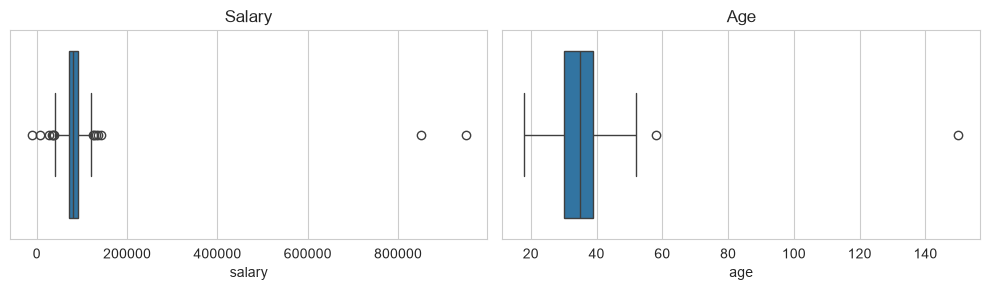

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.boxplot(x=df_clean["salary"], ax=axes[0]); axes[0].set_title("Salary")
sns.boxplot(x=df_clean["age"],    ax=axes[1]); axes[1].set_title("Age")
plt.tight_layout(); plt.show()

In [ ]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_bounds(df_clean["salary"])
print(f"Salary outlier bounds: {low:,.0f} to {high:,.0f}")
print("Salary outliers:", ((df_clean["salary"] < low) | (df_clean["salary"] > high)).sum())

# Look at the flagged rows before deciding anything!
df_clean[(df_clean["salary"] < low) | (df_clean["salary"] > high)][
    ["emp_id", "department", "experience", "salary"]]

Salary outlier bounds: 38,539 to 123,552
Salary outliers: 13


,emp_id,department,experience,salary
5,6,Engineering,10.5,950000.0
12,13,HR,6.2,850000.0
13,14,HR,6.3,37400.0
29,30,Engineering,4.1,131507.0
43,44,Marketing,3.9,32980.0
49,50,Marketing,13.8,127054.0
71,72,Finance,10.1,6735.0
73,74,Sales,4.4,-11210.0
74,75,Finance,8.0,36913.0
81,82,Marketing,11.4,136073.0


### Detection method 2: the Z-score

The Z-score measures **how many standard deviations** a value is from the mean:

$$ z = \frac{x - \text{mean}}{\text{std}} $$

A common threshold: **|z| > 3** → outlier. Best when the data is roughly
bell-shaped (normal). Caveat: the outliers themselves inflate the mean and std
used in the formula, so extreme outliers can "hide" smaller ones — which is why
IQR (based on percentiles, not the mean) is often more robust.

In [ ]:
z = (df_clean["salary"] - df_clean["salary"].mean()) / df_clean["salary"].std()

print("Salary values with |z| > 3:")
print(df_clean.loc[z.abs() > 3, "salary"].to_string())
print("\nCompare: IQR flagged", ((df_clean["salary"] < low) | (df_clean["salary"] > high)).sum(),
      "rows; Z-score flagged", (z.abs() > 3).sum(), "rows")

Salary values with |z| > 3:
5     950000.0
12    850000.0

Compare: IQR flagged 13 rows; Z-score flagged 2 rows


### Treating outliers — pick based on WHAT the outlier is

| Treatment | When | How |
|---|---|---|
| **Remove the row** | Clearly impossible / corrupted, and rare | boolean filter |
| **Fix it** | You can recover the true value (extra zero, wrong unit) | replace manually |
| **Cap / winsorize** | Real but extreme; you want to tame, not lose it | `.clip(lower, upper)` |
| **Transform (log)** | The whole column is skewed (salaries, prices, counts) | `np.log1p(x)` |
| **Keep it** | It's real and it's the signal (fraud, anomaly detection) | do nothing |

Below: **capping** for salary, a **sanity-range fix** for the impossible age,
and a **log transform** demo.

In [ ]:
# Cap salary to the IQR bounds (keeps the row, tames the extreme)
df_clean["salary"] = df_clean["salary"].clip(lower=low, upper=high)

# Age = 150 is impossible -> treat as an error and cap to a sane working range
df_clean["age"] = df_clean["age"].clip(lower=18, upper=65)

print("Salary max after capping:", df_clean["salary"].max())
print("Age max after capping:   ", df_clean["age"].max())

Salary max after capping: 123552.375
Age max after capping:    65.0


### (If time permits) Log transform for skewed data

Money-like columns are usually **right-skewed**: many small values, a long tail
of big ones. `np.log1p` (log(1+x), safe at 0) compresses the tail so the
distribution is more symmetric — often better for linear models than deleting
or capping anything.

/opt/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


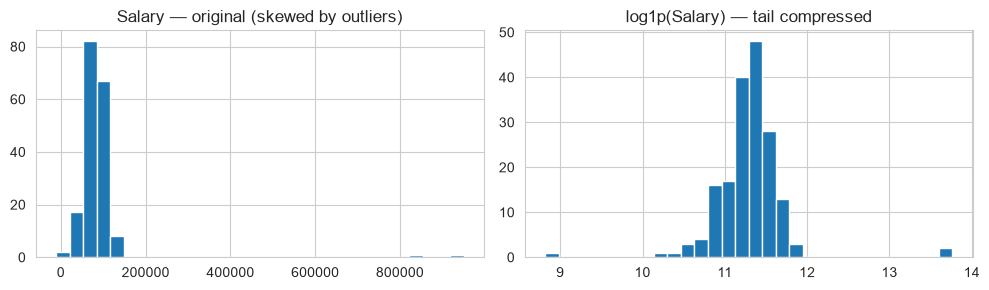

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(df["salary"].dropna(), bins=30)          # original (pre-capping)
axes[0].set_title("Salary — original (skewed by outliers)")
axes[1].hist(np.log1p(df["salary"].dropna()), bins=30)
axes[1].set_title("log1p(Salary) — tail compressed")
plt.tight_layout(); plt.show()

## 7. Encoding categorical variables

Models need **numbers**, not text. But *how* you convert matters — the wrong
encoding feeds the model false information.

### Step 1: classify each categorical column

| Type | Definition | Our examples | Right encoding |
|---|---|---|---|
| **Binary** | exactly 2 values | `gender`, `attrition` | map to 0/1 |
| **Ordinal** | categories with a natural ORDER | `education` (HS < Bachelor < Master < PhD) | ordinal encoding — integers that respect the order |
| **Nominal** | categories with NO order | `department`, `city` | one-hot encoding |

**Why not just number everything 0, 1, 2, 3?** If we encode
`Sales=0, HR=1, Finance=2`, the model reads that as *"Finance is twice HR"*
and *"Sales < HR < Finance"* — relationships that **don't exist**. That's why
nominal data gets one-hot encoding instead.

### Binary + ordinal encoding

ordinal example
hs = 0
bachelor = 1
master = 2
phd = 3

row_id , education
1           2
2           3


one hot encoding

high cardinatlity = high number of columns

embeddings = numerical representation of a word/sentece

embeddings_mode = x
x.create_embedding("apple") -> [0.1, 0.2, 0.3]

8000 categories in a column named "city"

one hot endocidng = 8000 columns

colors = ['red', 'green', 'blue',]

dataset columns
id, city, color,
1 , lah, red
2 , lah, green
3 , lah, blue

converted dataset after one hot encoding
id, city, color_red, color_green, color_blue
1 , lah,    1,          0,           0
2 , lah,    0,          1,           0
3 , lah,    0,          0,           1


converted dataset after one hot encoding
id, city, color
1 , lah,    [0.1, 0.2, 0.3]
2 , lah,    [0.4, 0.5, 0.6]
3 , lah,    [0.7, 0.8, 0.9]


row_id ,        color embedding
1               [0.1, 0.2, 0.3] # lahore
2               [0.4, 0.5, 0.6] # london
3               [0.7, 0.8, 0.9] # new york
4               [1.0, 1.1, 1.2] # delhi


cities = length of 800

convert those categorial columns into embeddings

In [ ]:
# Binary target -> map to 0/1
df_clean["attrition"] = df_clean["attrition"].map({"No": 0, "Yes": 1})

# gender is binary -> also fine to map to 0/1
df_clean["gender"] = df_clean["gender"].map({"M": 0, "F": 1})

# education is ORDINAL -> integers that respect the real-world order.
# We define the order explicitly; never let the computer guess (it would sort
# alphabetically: Bachelor=0, High School=1, ... which is wrong!)
edu_order = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df_clean["education"] = df_clean["education"].map(edu_order)

df_clean[["gender", "education", "attrition"]].head()

,gender,education,attrition
0,1,1,0
1,0,2,0
2,0,1,0
3,0,2,0
4,0,1,0


> 🛠️ **The scikit-learn way:** `OrdinalEncoder(categories=[["High School",
> "Bachelor", "Master", "PhD"]])` — same idea, pipeline-friendly. (There's also
> `LabelEncoder`, but it's meant for the **target** column only and picks the
> integer order alphabetically — a common beginner trap when used on features.)

### One-hot encoding for nominal columns

One-hot creates **one 0/1 column per category** — no fake order is introduced.

In [15]:
# Before: one column with 5 text values
print("department values:", sorted(df_clean["department"].unique()), "\n")

df_encoded = pd.get_dummies(df_clean, columns=["department", "city"], drop_first=True)

print("Columns after one-hot encoding:")
print(list(df_encoded.columns))
df_encoded.head(3)

department values: ['Engineering', 'Finance', 'HR', 'Marketing', 'Sales'] 

Columns after one-hot encoding:
['emp_id', 'age', 'gender', 'education', 'experience', 'salary', 'satisfaction', 'attrition', 'department_Finance', 'department_HR', 'department_Marketing', 'department_Sales', 'city_Karachi', 'city_Lahore', 'city_Multan', 'city_Peshawar']


,emp_id,age,gender,education,experience,salary,satisfaction,attrition,department_Finance,department_HR,department_Marketing,department_Sales,city_Karachi,city_Lahore,city_Multan,city_Peshawar
0,1,37.0,F,Bachelor,9.5,79692.0,1.0,No,True,False,False,False,False,True,False,False
1,2,27.0,M,Master,9.7,74476.0,3.0,No,True,False,False,False,False,False,False,True
2,3,41.0,M,Bachelor,9.6,77414.0,3.0,No,True,False,False,False,True,False,False,False


**Reading the result:** a Sales employee has `department_Sales = 1` and 0 in the
other department columns.

**Why `drop_first=True`?** With 5 departments, 4 columns are enough — if the 4
are all 0, the row must be the 5th (dropped) category. Keeping all 5 makes one
column perfectly predictable from the others (the **dummy variable trap**),
which hurts linear/statistical models. Tree models don't care either way.

### ⚠️ The high-cardinality problem (good to know)

One-hot explodes when a column has **many** unique values: a `city` column with
1,000 cities → 999 new columns of mostly zeros. Options for that case:

- **Group rare categories** into an `"Other"` bucket before one-hot
  (e.g., keep the top 10, lump the rest).
- **Frequency encoding** — replace each category with how often it occurs.
- **Target encoding** — replace each category with the average target value for
  that category (powerful but leaks easily; must be fit on training data only).

For our 5 departments and 5 cities, plain one-hot is perfect.

In [ ]:
# Mini-demo: frequency encoding (just to see the idea — we'll keep one-hot)
freq = df_clean["city"].value_counts(normalize=True)
print("Frequency encoding would map each city to its share of rows:")
print(freq.round(3).to_string())

Frequency encoding would map each city to its share of rows:
city
Lahore       0.270
Islamabad    0.195
Peshawar     0.180
Karachi      0.180
Multan       0.175


> Inside ML pipelines, prefer scikit-learn's `OneHotEncoder` over
> `pd.get_dummies`: it **remembers the categories it saw during training**, so
> new/unseen categories at prediction time don't crash or shift your columns
> (`handle_unknown="ignore"`).

## 8. Feature scaling

Features like `salary` (~80,000) and `satisfaction` (1–5) live on very
different scales. Distance- and gradient-based models (KNN, SVM, k-means,
logistic/linear regression, neural nets) are biased toward the big-number
features unless we scale.

| Scaler | What it does | Result |
|---|---|---|
| **StandardScaler** | subtract mean, divide by std | mean 0, std 1 |
| **MinMaxScaler** | rescale to a fixed range | values in [0, 1] |

> Tree-based models (Random Forest, XGBoost) don't need scaling — but it never
> hurts to understand it.

In [ ]:
0, 100, 100,000, 100,000,000

0 * 100
/
100,000,000

0% to 100%

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = ["age", "experience", "salary", "satisfaction"]

standard = StandardScaler().fit_transform(df_encoded[num_cols])
minmax   = MinMaxScaler().fit_transform(df_encoded[num_cols])

print("StandardScaler -> mean ~0, std ~1:")
print(pd.DataFrame(standard, columns=num_cols).describe().loc[["mean", "std"]].round(2))
print("\nMinMaxScaler -> values in [0, 1]:")
print(pd.DataFrame(minmax, columns=num_cols).describe().loc[["min", "max"]].round(2))

StandardScaler -> mean ~0, std ~1:
      age  experience  salary  satisfaction
mean -0.0        -0.0    -0.0           0.0
std   1.0         1.0     1.0           1.0

MinMaxScaler -> values in [0, 1]:
     age  experience  salary  satisfaction
min  0.0         0.0     0.0           0.0
max  1.0         1.0     1.0           1.0


## 9. Train/test split — and avoiding **data leakage**

⚠️ **Critical rule:** split your data *first*, then `fit` scalers/imputers on
the **training set only** and `transform` the test set. If you scale using the
whole dataset, information from the test set "leaks" into training and your
scores look better than reality.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["attrition", "emp_id"])
y = df_encoded["attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Correct: fit on TRAIN only, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])   # fit + transform
X_test_scaled  = scaler.transform(X_test[num_cols])        # transform ONLY
print("Scaler fitted on training data only ✔ (no leakage)")

Train: (160, 14)  Test: (40, 14)
Scaler fitted on training data only ✔ (no leakage)


## 10. Bonus — putting it all together with a `Pipeline`

In practice you bundle these steps into a `ColumnTransformer` + `Pipeline` so
the exact same preprocessing is applied consistently to train, test, and future
data — with no leakage and no repeated code.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Start from the raw (only lightly cleaned) data to show a realistic pipeline
raw = pd.read_csv("employees_messy.csv").drop_duplicates()
raw["attrition"] = raw["attrition"].map({"No": 0, "Yes": 1})

numeric_features = ["age", "experience", "salary", "satisfaction"]
categorical_features = ["department", "city"]
ordinal_features = ["education"]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])
ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[["High School", "Bachelor", "Master", "PhD"]])),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
    ("ord", ordinal_pipe, ordinal_features),
])

Xr = raw[numeric_features + categorical_features + ordinal_features]
yr = raw["attrition"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

Xr_train_processed = preprocessor.fit_transform(Xr_train)
Xr_test_processed  = preprocessor.transform(Xr_test)
print("Processed training matrix shape:", Xr_train_processed.shape)
print("One clean, reusable, leakage-free preprocessing object ✔")

Processed training matrix shape: (160, 16)
One clean, reusable, leakage-free preprocessing object ✔


## 11. Recap — your preprocessing checklist

1. **Explore**: `head`, `shape`, `info`, `describe`, `isnull().sum()`
2. **Missing values**: ask *why* it's missing → drop, impute (median for skewed
   numbers, mode for categories), group-wise impute, or add a missing indicator
3. **Duplicates**: `duplicated()` → `drop_duplicates()`
4. **Dirty text**: strip whitespace, fix casing, unify categories
5. **Outliers**: detect with IQR / Z-score / boxplot → then decide per case:
   error → fix/remove; real but extreme → cap; skewed column → log transform;
   real signal → keep
6. **Encode**: classify first! binary → 0/1, ordinal → ordered integers
   (define the order yourself), nominal → one-hot; high-cardinality → group
   rare / frequency / target encoding
7. **Scale**: StandardScaler / MinMaxScaler for distance & gradient models
8. **Split first**, fit on train only → **no data leakage**
9. **Automate** with `Pipeline` + `ColumnTransformer`

> Order matters, but adapt to your data. The goal: clean, consistent, numeric,
> appropriately-scaled features your model can actually learn from.

---
# 📝 Take-home assignments

Practice on a **real** dataset. The classic **Titanic** dataset is perfect and
loads with one line (needs internet):

```python
import seaborn as sns
titanic = sns.load_dataset("titanic")
```
*(Alternatively use any CSV you like — or the `employees_messy.csv` from today.)*

### Assignment 1 — Explore & report (warm-up)
- Load the Titanic dataset and print its shape, `info()`, and `describe()`.
- Which columns have missing values, and what **percentage** is missing in each?
- Write 2–3 sentences describing the problems you found.

### Assignment 2 — Missing values
- The `age` column has many missing values. Fill them using the **median**.
- The `embarked` / `embark_town` column has a few missing values. Fill them with
  the **mode**.
- The `deck` column is *mostly* empty — decide whether to drop it and justify.

### Assignment 3 — Outliers
- Draw a boxplot of `fare`. Are there outliers?
- Use the **IQR rule** to count how many `fare` values are outliers, then use
  the **Z-score rule** (|z| > 3). Do the two methods agree? Why might they differ?
- Cap the `fare` outliers and re-draw the boxplot. Describe the difference.
- Bonus: plot a histogram of `fare` and of `np.log1p(fare)`. Which looks more
  symmetric, and why might a model prefer it?

### Assignment 4 — Encoding
- Convert `sex` into numbers (binary 0/1 mapping).
- The `class` column (First / Second / Third) is **ordinal** — encode it with
  integers that respect the order, defining the order yourself.
- One-hot encode `embarked` (or `embark_town`).
- Explain in one sentence **why** `embarked` gets one-hot but `class` gets
  ordered integers.

### Assignment 5 — Scaling & split
- Do a **train/test split** (80/20) with `survived` as the target.
- Apply `StandardScaler` **correctly** — fit on train only, transform both.
- Explain what "data leakage" is and how your code avoided it.

### ⭐ Bonus (stretch goal)
- Rebuild your entire Assignment-2-to-5 workflow as a single scikit-learn
  `Pipeline` + `ColumnTransformer`.
- Train a simple `LogisticRegression` on the processed data and report its
  accuracy on the test set.

**Deliverable:** one notebook with code + short markdown explanations for each
step. Focus on *explaining your choices*, not just running code.